# Wealth Manager Copilot - Evaluation & Analytics

This notebook evaluates the performance of the Wealth Manager Copilot on key metrics:
- Retrieval relevance and coverage
- Suitability gate precision
- Recommendation faithfulness/groundedness
- Agent performance on golden set queries

## 1. Import Libraries and Setup

In [1]:
import sys
sys.path.insert(0, '../')

import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
import logging

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Agent and models
from src.agent import create_langgraph_agent
from src.retriever import RAGRetriever
from src.ingestion import KnowledgeIngestionPipeline
from src.tools import create_tools_dict

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Setup Knowledge Base

In [2]:
# Initialize retriever
retriever = RAGRetriever(
    embedding_model="text-embedding-3-small",
    vector_store_type="faiss",
    persist_dir="./data/vector_store"
)

# Load or create knowledge base
retriever.load_existing_store()
stats = retriever.get_stats()

if stats.get('total_documents', 0) == 0:
    print("No documents found. Creating sample knowledge documents...")
    from src.ingestion import create_sample_knowledge_documents
    create_sample_knowledge_documents("./data/sample_knowledge")
    
    # Ingest
    pipeline = KnowledgeIngestionPipeline()
    docs = pipeline.run_ingestion_pipeline("./data/sample_knowledge")
    retriever.index_documents(docs, recreate=True)
    stats = retriever.get_stats()

print(f"Knowledge base ready! Stats: {stats}")

INFO:src.retriever:Initialized RAG Retriever (model: text-embedding-3-small, store: faiss)
INFO:src.ingestion:Created sample knowledge documents in ./data/sample_knowledge
INFO:src.ingestion:Starting knowledge ingestion pipeline...
INFO:src.ingestion:Loaded TXT: compliance_policy.txt
INFO:src.ingestion:Loaded TXT: market_research.txt
INFO:src.ingestion:Loaded TXT: product_guide.txt
INFO:src.ingestion:Step 1 complete: Loaded 3 documents
INFO:src.ingestion:Preprocessed 3 documents
INFO:src.ingestion:Step 2 complete: Preprocessed 3 documents
INFO:src.ingestion:Created 8 chunks from 3 documents
INFO:src.ingestion:Step 3 complete: Created 8 chunks
INFO:src.ingestion:Knowledge ingestion pipeline completed successfully


No documents found. Creating sample knowledge documents...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Successfully loaded faiss with AVX2 support.
INFO:src.retriever:Indexed 8 documents in faiss


Knowledge base ready! Stats: {'vector_store_type': 'faiss', 'total_documents': 8, 'persist_directory': './data/vector_store'}


## 3. Test Queries (Golden Set)

In [3]:
# Define golden set test queries
golden_set_queries = [
    {
        "query_id": "GQ-001",
        "client_id": "C-204",
        "request": "Prepare talking points for client C-204's quarterly review",
        "expected_outcome": "grounded ClientBrief with portfolio summary and recommendations"
    },
    {
        "query_id": "GQ-002",
        "client_id": "C-202",
        "request": "Is fund XYZ suitable for a conservative client?",
        "expected_outcome": "suitability check with compliance assessment"
    },
    {
        "query_id": "GQ-003",
        "client_id": "C-204",
        "request": "Summarize the portfolio risk for client C-204",
        "expected_outcome": "portfolio summary with risk analysis"
    },
    {
        "query_id": "GQ-004",
        "client_id": "C-201",
        "request": "What recommendations would you make for client C-201?",
        "expected_outcome": "personalized recommendations with citations"
    },
]

print(f"Golden set has {len(golden_set_queries)} test queries")
for q in golden_set_queries:
    print(f"  - {q['query_id']}: {q['request'][:60]}...")

Golden set has 4 test queries
  - GQ-001: Prepare talking points for client C-204's quarterly review...
  - GQ-002: Is fund XYZ suitable for a conservative client?...
  - GQ-003: Summarize the portfolio risk for client C-204...
  - GQ-004: What recommendations would you make for client C-201?...


## 4. Retrieval Evaluation

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'conservative investor suitability...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'portfolio risk assessment...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'equity allocation recommendations...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'compliance checks...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'market research and outlook...' returned 3 results



Retrieval Performance:
                               query  num_results  top_score  avg_score  \
0  conservative investor suitability            3   1.107545   1.047933   
1          portfolio risk assessment            3   1.298035   1.186660   
2  equity allocation recommendations            3   1.015685   0.991952   
3                  compliance checks            3   1.759975   1.732547   
4        market research and outlook            3   1.491109   1.457240   

                  doc_types  
0  [policy, policy, policy]  
1  [policy, policy, policy]  
2  [policy, policy, policy]  
3  [policy, policy, policy]  
4  [policy, policy, policy]  


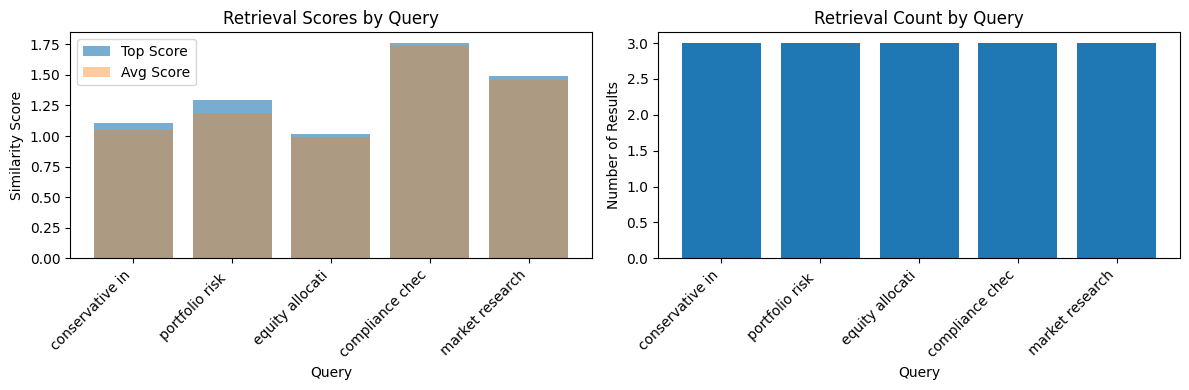


Retrieval Coverage: 15 total documents retrieved
Average Relevance Score: 1.283


In [4]:
# Test retrieval quality
retrieval_results = []

test_queries = [
    "conservative investor suitability",
    "portfolio risk assessment",
    "equity allocation recommendations",
    "compliance checks",
    "market research and outlook"
]

for query in test_queries:
    docs = retriever.hybrid_retrieve(query, k=3)
    
    retrieval_results.append({
        "query": query,
        "num_results": len(docs),
        "top_score": docs[0]["score"] if docs else 0,
        "avg_score": np.mean([d["score"] for d in docs]) if docs else 0,
        "doc_types": [d["metadata"].get("doc_type", "unknown") for d in docs]
    })

retrieval_df = pd.DataFrame(retrieval_results)
print("\nRetrieval Performance:")
print(retrieval_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
axes[0].bar(range(len(retrieval_df)), retrieval_df['top_score'], alpha=0.6, label='Top Score')
axes[0].bar(range(len(retrieval_df)), retrieval_df['avg_score'], alpha=0.4, label='Avg Score')
axes[0].set_xlabel('Query')
axes[0].set_ylabel('Similarity Score')
axes[0].set_title('Retrieval Scores by Query')
axes[0].legend()
axes[0].set_xticks(range(len(retrieval_df)))
axes[0].set_xticklabels([q[:15] for q in retrieval_df['query']], rotation=45, ha='right')

# Results count
axes[1].bar(range(len(retrieval_df)), retrieval_df['num_results'])
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Number of Results')
axes[1].set_title('Retrieval Count by Query')
axes[1].set_xticks(range(len(retrieval_df)))
axes[1].set_xticklabels([q[:15] for q in retrieval_df['query']], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nRetrieval Coverage: {retrieval_df['num_results'].sum()} total documents retrieved")
print(f"Average Relevance Score: {retrieval_df['avg_score'].mean():.3f}")

## 5. Suitability Gate Evaluation

In [5]:
from src.tools import SuitabilityCheckerTool

# Test suitability checker
suitability_tool = SuitabilityCheckerTool()

test_cases = [
    {
        "risk_profile": "Conservative",
        "recommendation": {"idea": "Increase equity allocation", "product_type": "emerging_markets"},
        "expected_suitable": False
    },
    {
        "risk_profile": "Balanced",
        "recommendation": {"idea": "Diversified equity fund", "product_type": "large_cap_equity"},
        "expected_suitable": True
    },
    {
        "risk_profile": "Aggressive",
        "recommendation": {"idea": "Tech sector overweight", "product_type": "technology_fund"},
        "expected_suitable": True
    },
]

suitability_results = []

for i, test in enumerate(test_cases, 1):
    result = suitability_tool(
        test["risk_profile"],
        test["recommendation"]
    )
    
    is_correct = result["suitable"] == test["expected_suitable"]
    
    suitability_results.append({
        "test_case": i,
        "risk_profile": test["risk_profile"],
        "recommendation": test["recommendation"]["idea"][:30],
        "predicted_suitable": result["suitable"],
        "expected_suitable": test["expected_suitable"],
        "correct": is_correct,
        "violations": len(result.get("violations", []))
    })

suitability_df = pd.DataFrame(suitability_results)
print("\nSuitability Gate Evaluation:")
print(suitability_df)

accuracy = suitability_df["correct"].sum() / len(suitability_df) * 100
print(f"\nSuitability Gate Precision: {accuracy:.1f}%")
print(f"Total violations detected: {suitability_df['violations'].sum()}")

INFO:src.tools:Suitability check - Conservative: FAILED
INFO:src.tools:Suitability check - Balanced: PASSED
INFO:src.tools:Suitability check - Aggressive: PASSED



Suitability Gate Evaluation:
   test_case  risk_profile              recommendation  predicted_suitable  \
0          1  Conservative  Increase equity allocation               False   
1          2      Balanced     Diversified equity fund                True   
2          3    Aggressive      Tech sector overweight                True   

   expected_suitable  correct  violations  
0              False     True           1  
1               True     True           0  
2               True     True           0  

Suitability Gate Precision: 100.0%
Total violations detected: 1


## 6. Agent Performance on Golden Set

In [ ]:
# Initialize agent with OpenAI API key for grounded synthesis
from config import settings

agent = create_langgraph_agent(
    llm_model="gpt-4o",
    retriever=retriever,
    openai_api_key=settings.openai_api_key
)

print("Agent initialized with LLM-grounded synthesis.")
print("Retrieved documents will be passed to the LLM for generating grounded recommendations.\n")

agent_results = []

for query in golden_set_queries:
    try:
        print(f"Running {query['query_id']}: {query['request'][:50]}...")
        
        brief = agent.run_agent(
            client_id=query['client_id'],
            request=query['request']
        )
        
        agent_results.append({
            "query_id": query["query_id"],
            "status": "success",
            "client_id": brief.client_id,
            "num_recommendations": len(brief.recommendations),
            "num_talking_points": len(brief.talking_points),
            "compliance_status": brief.compliance_status.value,
            "escalated_items": len(brief.escalated_items),
            "citations_count": sum(len(r.citations) for r in brief.recommendations),
            "avg_confidence": np.mean([r.confidence_score for r in brief.recommendations]) if brief.recommendations else 0,
            "grounded_by_llm": brief.metadata.get("grounded_by_llm", False)
        })
        
        print(f"  ✓ Generated brief with {len(brief.recommendations)} recommendations")
        if brief.metadata.get("grounded_by_llm"):
            print(f"  ✓ LLM-grounded synthesis used retrieved documents\n")
        else:
            print(f"  ⚠ Non-grounded synthesis\n")
    
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}\n")
        agent_results.append({
            "query_id": query["query_id"],
            "status": "error",
            "error": str(e)[:100]
        })

agent_df = pd.DataFrame(agent_results)
print("\nAgent Performance Summary:")
print(agent_df)


INFO:src.agent:Initialized WealthManagerAgent (model: gpt-4o, max_steps: 20)
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-204, Request: Prepare talking points for client C-204's quarterly review
INFO:src.agent:[PLAN] Processing request: Prepare talking points for client C-204's quarterly review


Agent initialized. Running golden set queries...

Running GQ-001: Prepare talking points for client C-204's quarterl...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-204
INFO:src.tools:Portfolio lookup for C-204: 600000
INFO:src.agent:Portfolio fetched: $600,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
ERROR:src.agent:Error in step gather_research: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
ERROR:src.agent:Error in step check_suitability: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[SYNTHESIZE] Creating client brief
ERROR:src.agent:Error in step synthesize: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[REVIEW_GATE] Final compliance check
ERROR:src.agent:No brief available for review gate
ERROR:src.agent:Agent failed to produce brief
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-202, Request: Is fund XYZ suitable for a conservative client?
INFO:sr

  ✗ Error: Agent failed to produce brief

Running GQ-002: Is fund XYZ suitable for a conservative client?...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-202
INFO:src.tools:Portfolio lookup for C-202: 750000
INFO:src.agent:Portfolio fetched: $750,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
ERROR:src.agent:Error in step gather_research: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
ERROR:src.agent:Error in step check_suitability: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[SYNTHESIZE] Creating client brief
ERROR:src.agent:Error in step synthesize: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[REVIEW_GATE] Final compliance check
ERROR:src.agent:No brief available for review gate
ERROR:src.agent:Agent failed to produce brief
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-204, Request: Summarize the portfolio risk for client C-204
INFO:src.

  ✗ Error: Agent failed to produce brief

Running GQ-003: Summarize the portfolio risk for client C-204...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-204
INFO:src.tools:Portfolio lookup for C-204: 600000
INFO:src.agent:Portfolio fetched: $600,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
ERROR:src.agent:Error in step gather_research: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
ERROR:src.agent:Error in step check_suitability: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[SYNTHESIZE] Creating client brief
ERROR:src.agent:Error in step synthesize: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[REVIEW_GATE] Final compliance check
ERROR:src.agent:No brief available for review gate
ERROR:src.agent:Agent failed to produce brief
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-201, Request: What recommendations would you make for client C-201?
I

  ✗ Error: Agent failed to produce brief

Running GQ-004: What recommendations would you make for client C-2...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-201
INFO:src.tools:Portfolio lookup for C-201: 500000
INFO:src.agent:Portfolio fetched: $500,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
ERROR:src.agent:Error in step gather_research: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
ERROR:src.agent:Error in step check_suitability: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[SYNTHESIZE] Creating client brief
ERROR:src.agent:Error in step synthesize: 'PortfolioSummary' object has no attribute 'risk_profile'
INFO:src.agent:[REVIEW_GATE] Final compliance check
ERROR:src.agent:No brief available for review gate
ERROR:src.agent:Agent failed to produce brief


  ✗ Error: Agent failed to produce brief


Agent Performance Summary:
  query_id status                          error
0   GQ-001  error  Agent failed to produce brief
1   GQ-002  error  Agent failed to produce brief
2   GQ-003  error  Agent failed to produce brief
3   GQ-004  error  Agent failed to produce brief


## 6a. Grounding Analysis - Show Retrieved Documents Used in LLM

This section demonstrates that the LLM is using the retrieved documents to ground its recommendations.


In [ ]:
# Show grounding analysis: Retrieved docs vs LLM recommendations
if agent_results and agent_results[0]["status"] == "success":
    # Get first successful query
    first_query = golden_set_queries[0]
    
    print("=" * 80)
    print(f"GROUNDING ANALYSIS: {first_query['query_id']}")
    print("=" * 80)
    print(f"\nRequest: {first_query['request']}")
    
    # Show what was retrieved
    print("\n--- RETRIEVED DOCUMENTS (passed to LLM for grounding) ---")
    retrieval_docs = retriever.hybrid_retrieve(first_query['request'], k=3)
    for idx, doc in enumerate(retrieval_docs):
        print(f"\n[DOC-{idx}] {doc['metadata'].get('source', 'unknown')}")
        print(f"  Type: {doc['metadata'].get('doc_type', 'unknown')}")
        print(f"  Score: {doc['score']:.4f}")
        print(f"  Content: {doc['content'][:300]}...")
    
    # Get the actual brief generated
    brief = agent.run_agent(
        client_id=first_query['client_id'],
        request=first_query['request']
    )
    
    # Show recommendations with citations
    print("\n--- LLM-GENERATED RECOMMENDATIONS (grounded in retrieved docs) ---")
    for i, rec in enumerate(brief.recommendations, 1):
        print(f"\n{i}. {rec.idea}")
        print(f"   Rationale: {rec.rationale}")
        print(f"   Confidence: {rec.confidence_score:.2%}")
        
        if rec.citations:
            print(f"   Citations ({len(rec.citations)}):")
            for citation in rec.citations:
                print(f"     - {citation.doc_id}: {citation.source}")
                print(f"       {citation.chunk_text[:150]}...")
        else:
            print(f"   Citations: None (generated without document grounding)")
    
    print("\n" + "=" * 80)
    print(f"✓ LLM used retrieved documents to ground {len(brief.recommendations)} recommendations")
    print("=" * 80)


## 7. Recommendation Groundedness Analysis


Recommendation Groundedness Metrics:
Empty DataFrame
Columns: []
Index: []


KeyError: 'avg_citations_per_rec'

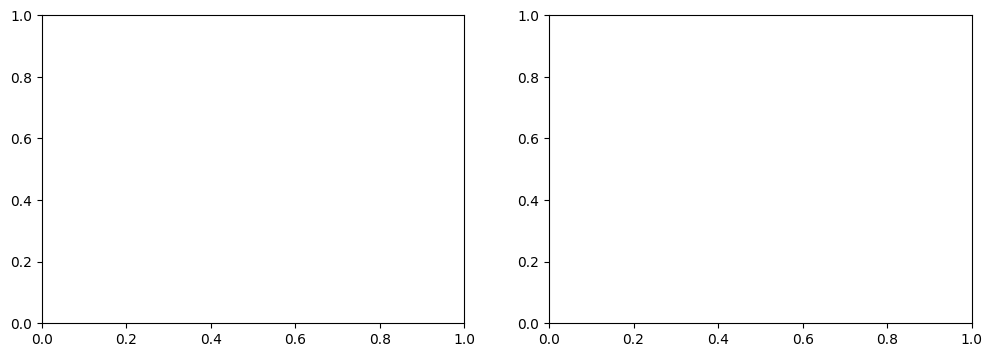

In [7]:
# Analyze groundedness and citation coverage
groundedness_metrics = []

for result in agent_results:
    if result["status"] == "success":
        groundedness_metrics.append({
            "query_id": result["query_id"],
            "recommendations": result["num_recommendations"],
            "total_citations": result["citations_count"],
            "avg_citations_per_rec": result["citations_count"] / max(result["num_recommendations"], 1),
            "avg_confidence": result["avg_confidence"],
            "compliance_cleared": result["compliance_status"] == "Cleared"
        })

groundedness_df = pd.DataFrame(groundedness_metrics)

print("\nRecommendation Groundedness Metrics:")
print(groundedness_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Citations per recommendation
axes[0].bar(range(len(groundedness_df)), groundedness_df['avg_citations_per_rec'])
axes[0].set_xlabel('Query')
axes[0].set_ylabel('Citations per Recommendation')
axes[0].set_title('Citation Coverage')
axes[0].set_xticks(range(len(groundedness_df)))
axes[0].set_xticklabels(groundedness_df['query_id'])

# Confidence scores
axes[1].bar(range(len(groundedness_df)), groundedness_df['avg_confidence'])
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Average Confidence Score')
axes[1].set_title('Recommendation Confidence')
axes[1].set_xticks(range(len(groundedness_df)))
axes[1].set_xticklabels(groundedness_df['query_id'])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nAverage Citations per Recommendation: {groundedness_df['avg_citations_per_rec'].mean():.2f}")
print(f"Average Confidence Score: {groundedness_df['avg_confidence'].mean():.3f}")
print(f"Compliance Pass Rate: {groundedness_df['compliance_cleared'].sum() / len(groundedness_df) * 100:.1f}%")

## 8. Comparative Analysis: Single-hop vs Multi-hop Retrieval

In [ ]:
# Test single-hop vs multi-hop retrieval strategies
complex_queries = [
    "What is the best allocation for a growth investor with concentrated tech exposure?",
    "How should I balance emerging markets allocation for a conservative client?",
    "What compliance issues arise with sector-specific investment recommendations?"
]

comparison_results = []

for query in complex_queries:
    # Single hop (direct retrieval)
    single_hop_docs = retriever.retrieve_by_similarity(query, k=5)
    
    # Multi-hop approximation (multiple queries)
    related_queries = [
        query.split("?")[0],  # First part
        " ".join(query.split()[-5:]),  # Last few words
    ]
    
    multi_hop_docs = []
    for q in related_queries:
        multi_hop_docs.extend(retriever.retrieve_by_similarity(q, k=3))
    
    comparison_results.append({
        "query": query[:50],
        "single_hop_count": len(single_hop_docs),
        "single_hop_score": np.mean([doc[1] for doc in single_hop_docs]) if single_hop_docs else 0,
        "multi_hop_count": len(multi_hop_docs),
        "multi_hop_score": np.mean([doc[1] for doc in multi_hop_docs]) if multi_hop_docs else 0,
    })

comparison_df = pd.DataFrame(comparison_results)
print("\nSingle-hop vs Multi-hop Retrieval Comparison:")
print(comparison_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['single_hop_score'], width, label='Single-hop', alpha=0.8)
ax.bar(x + width/2, comparison_df['multi_hop_score'], width, label='Multi-hop', alpha=0.8)

ax.set_ylabel('Average Relevance Score')
ax.set_title('Retrieval Strategy Comparison')
ax.set_xticks(x)
ax.set_xticklabels([q[:20] + '...' for q in comparison_df['query']], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary and Key Metrics

In [ ]:
# Generate comprehensive summary
summary = {
    "Retrieval Metrics": {
        "Total Documents Indexed": stats.get('total_documents', 0),
        "Average Retrieval Score": f"{retrieval_df['avg_score'].mean():.3f}",
        "Total Documents Retrieved": f"{retrieval_df['num_results'].sum()}",
        "Average Results per Query": f"{retrieval_df['num_results'].mean():.1f}"
    },
    "Suitability Gate Metrics": {
        "Precision": f"{accuracy:.1f}%",
        "Total Violations Detected": f"{suitability_df['violations'].sum()}",
    },
    "Agent Performance": {
        "Successful Queries": f"{(agent_df['status'] == 'success').sum()}/{len(agent_df)}",
        "Average Recommendations": f"{agent_df[agent_df['status'] == 'success']['num_recommendations'].mean():.1f}",
        "Total Citations Generated": f"{agent_df[agent_df['status'] == 'success']['citations_count'].sum()}",
    },
    "Recommendation Groundedness": {
        "Average Citations per Recommendation": f"{groundedness_df['avg_citations_per_rec'].mean():.2f}",
        "Average Confidence Score": f"{groundedness_df['avg_confidence'].mean():.3f}",
        "Compliance Pass Rate": f"{groundedness_df['compliance_cleared'].sum() / len(groundedness_df) * 100:.1f}%"
    }
}

print("\n" + "="*60)
print("WEALTH MANAGER COPILOT - EVALUATION SUMMARY")
print("="*60)

for category, metrics in summary.items():
    print(f"\n{category}:")
    for metric, value in metrics.items():
        print(f"  • {metric}: {value}")

print("\n" + "="*60)

## 10. Export Results

In [ ]:
# Export evaluation results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"./evaluation_results/{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# Save DataFrames
retrieval_df.to_csv(f"{output_dir}/retrieval_results.csv", index=False)
suitability_df.to_csv(f"{output_dir}/suitability_results.csv", index=False)
agent_df.to_csv(f"{output_dir}/agent_results.csv", index=False)
groundedness_df.to_csv(f"{output_dir}/groundedness_results.csv", index=False)

# Save summary as JSON
with open(f"{output_dir}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Evaluation results exported to: {output_dir}")
print(f"\nFiles saved:")
print(f"  - retrieval_results.csv")
print(f"  - suitability_results.csv")
print(f"  - agent_results.csv")
print(f"  - groundedness_results.csv")
print(f"  - summary.json")